<a href="https://colab.research.google.com/github/akarshanagarwal8-ai/AQI-Prediction/blob/main/pbl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving global_energy_consumption.csv.xlsx to global_energy_consumption.csv.xlsx
Columns: Index(['Country', 'Year', 'Total Energy Consumption (TWh)',
       'Per Capita Energy Use (kWh)', 'Renewable Energy Share (%)',
       'Fossil Fuel Dependency (%)', 'Industrial Energy Use (%)',
       'Household Energy Use (%)', 'Carbon Emissions (Million Tons)',
       'Energy Price Index (USD/kWh)'],
      dtype='object')
Year column: Year
Target column: Energy Price Index (USD/kWh)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Epoch 1/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - loss: 0.0872
Epoch 2/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0856
Epoch 3/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0853
Epoch 4/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0851
Epoch 5/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0849
Epoch 6/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.0848
Epoch 7/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.0848
Epoch 8/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.0847
Epoch 9/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 0.0847
Epoch 10/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 0.0847
Epoch 11/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - loss: 0.0846
Epoch 12/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.0846
Epoch 13/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 0.0847
Epoch 14/20
7996/7996 ━━━━━━━━━━━━━━━━━━━━ 34s 4ms/step - loss: 0.0845
Epoch 15/20
799

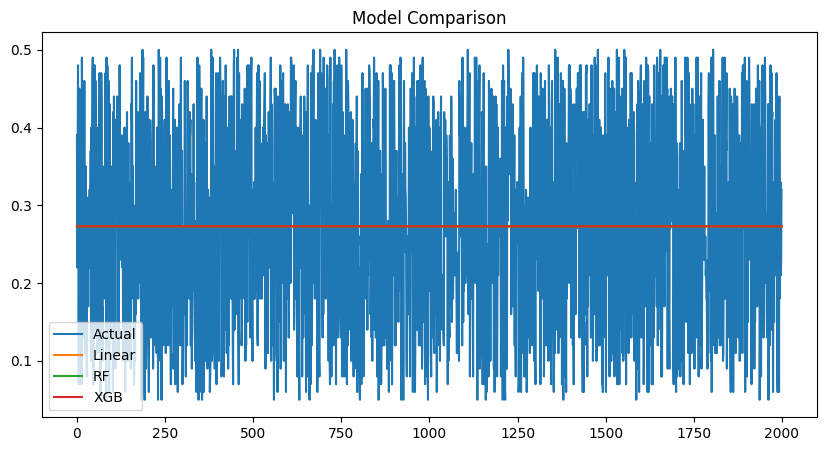

In [4]:
# ================================
# STEP 1: INSTALL LIBRARIES
# ================================
!pip install xgboost statsmodels tensorflow openpyxl

# ================================
# STEP 2: IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# ================================
# STEP 3: UPLOAD FILE
# ================================
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# Detect file type
if file_name.endswith('.xlsx'):
    df = pd.read_excel(file_name)
else:
    df = pd.read_csv(file_name)

# ================================
# STEP 4: CLEAN COLUMN NAMES
# ================================
df.columns = df.columns.str.strip()
print("Columns:", df.columns)

# ================================
# STEP 5: FIND YEAR COLUMN
# ================================
year_col = None
for col in df.columns:
    if 'year' in col.lower():
        year_col = col

if year_col is None:
    raise Exception("❌ No YEAR column found")

print("Year column:", year_col)

# ================================
# STEP 6: SELECT TARGET COLUMN
# ================================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if year_col in numeric_cols:
    numeric_cols.remove(year_col)

target_col = numeric_cols[-1]   # last numeric column
print("Target column:", target_col)

# ================================
# STEP 7: PREPROCESSING
# ================================
df = df[[year_col, target_col]].dropna()

df[year_col] = pd.to_datetime(df[year_col], errors='coerce')
df = df.dropna()

df = df.sort_values(year_col)

# Convert year → number
X = df[[year_col]].apply(lambda x: x.map(lambda y: y.year))
y = df[target_col]

# ================================
# STEP 8: TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ================================
# STEP 9: SCALING (LSTM)
# ================================
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.values.reshape(-1,1))

# ================================
# STEP 10: MACHINE LEARNING MODELS
# ================================

# Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor().fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost
xgb = XGBRegressor().fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

# AdaBoost
ada = AdaBoostRegressor().fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

# ================================
# STEP 11: ARIMA
# ================================
model_arima = ARIMA(y, order=(2,1,2))
model_arima_fit = model_arima.fit()
y_pred_arima = model_arima_fit.forecast(steps=len(y_test))

# ================================
# STEP 12: LSTM
# ================================
def create_dataset(dataset, time_step=3):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 3
X_lstm, y_lstm = create_dataset(y_scaled, time_step)

X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

train_size = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:train_size], X_lstm[train_size:]
y_train_lstm, y_test_lstm = y_lstm[:train_size], y_lstm[train_size:]

model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train_lstm, y_train_lstm, epochs=20, batch_size=1, verbose=1)

y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

# ================================
# STEP 13: EVALUATION
# ================================
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")
evaluate(y_test, y_pred_ada, "AdaBoost")
evaluate(y_test, y_pred_arima, "ARIMA")

min_len = min(len(y_test_lstm), len(y_pred_lstm))
evaluate(y_test_lstm[:min_len], y_pred_lstm[:min_len], "LSTM")

# ================================
# STEP 14: PLOT
# ================================
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_lr, label="Linear")
plt.plot(y_pred_rf, label="RF")
plt.plot(y_pred_xgb, label="XGB")
plt.legend()
plt.title("Model Comparison")
plt.show()